# Análise do challenge 004: posts, engajamento e patrocínio

Este notebook gera os números do laudo do dado (`../01_laudo_do_dado.md`, seção 1) e da análise (`../02_analise.md`, seção 2). Cada seção diz o que está sendo conferido e por quê. Para rodar do zero, siga o README da submissão.

In [1]:
import sys
from pathlib import Path

PASTA_SOLUCAO = Path.cwd().resolve().parent  # o notebook roda dentro de solution/notebooks/
sys.path.insert(0, str(PASTA_SOLUCAO))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter
from scipy import stats

from src.dados import carregar
from src.formato import numero_br, percentual_br
from src.laudo import indice_dispersao, proporcao_esperada_uniforme, usa_escrita_nao_latina, variacao_seguidores
from src.metricas import FAIXAS, LIMITES_FAIXA, adicionar_metricas

# Cores validadas para daltonismo e contraste sobre o fundo claro
AZUL, LARANJA = "#2a78d6", "#eb6834"
FUNDO, TINTA, TINTA_2, GRADE, EIXO = "#fcfcfb", "#0b0b0b", "#52514e", "#e1e0d9", "#c3c2b7"
plt.rcParams.update({
    "figure.facecolor": FUNDO, "axes.facecolor": FUNDO, "savefig.facecolor": FUNDO,
    "axes.edgecolor": EIXO, "axes.grid": True, "grid.color": GRADE, "grid.linewidth": 1,
    "axes.spines.top": False, "axes.spines.right": False, "axes.axisbelow": True,
    "text.color": TINTA, "axes.labelcolor": TINTA_2, "xtick.color": TINTA_2, "ytick.color": TINTA_2,
    "font.size": 10, "axes.titlesize": 11, "figure.dpi": 110,
})

bruto = carregar()
df = adicionar_metricas(bruto)
print(f"{numero_br(len(bruto))} posts e {bruto.shape[1]} colunas no CSV, "
      f"de {df['post_date'].min():%d/%m/%Y} a {df['post_date'].max():%d/%m/%Y}")

52.214 posts e 27 colunas no CSV, de 29/05/2023 a 28/05/2025


## 1. Laudo do dado

Antes de perguntar o que dá resultado, vale conferir se o arquivo consegue responder. São quatro testes simples (1.1 a 1.4). A seção 1.5 mostra que o método de análise acha efeitos quando eles existem.

### 1.1 Teste 1: cada métrica se comporta como um sorteio em torno de um valor fixo

Se um número é sorteado ao acaso em torno de uma média fixa (distribuição de Poisson), a variância fica igual à média e o **índice de dispersão** (variância dividida pela média) dá 1. Quando plataforma, formato, creator ou patrocínio mudam o resultado dos posts, as médias variam de um grupo para outro e o índice fica acima de 1. Índice igual a 1 quer dizer que nada além do sorteio explica a diferença entre um post e outro.

In [2]:
METRICAS = {"views": "views", "likes": "likes", "shares": "shares", "comentários": "comments_count"}
teste1 = pd.DataFrame(
    {
        nome: {
            "média": df[coluna].mean(),
            "desvio-padrão": df[coluna].std(),
            "raiz da média": np.sqrt(df[coluna].mean()),
            "mínimo": df[coluna].min(),
            "máximo": df[coluna].max(),
            "índice de dispersão": indice_dispersao(df[coluna]),
        }
        for nome, coluna in METRICAS.items()
    }
).T
(
    teste1.style.format(lambda v: numero_br(v, 2))
    .format(lambda v: numero_br(v, 0), subset=["mínimo", "máximo"])
    .format(lambda v: numero_br(v, 3), subset=["índice de dispersão"])
)

,média,desvio-padrão,raiz da média,mínimo,máximo,índice de dispersão
views,"10.100,28","100,03","100,50",9.676,10.551,"0,991"
likes,"1.510,27","38,92","38,86",1.354,1.668,"1,003"
shares,"300,02","17,31","17,32",227,380,"0,999"
comentários,"200,02","14,09","14,14",140,258,"0,993"


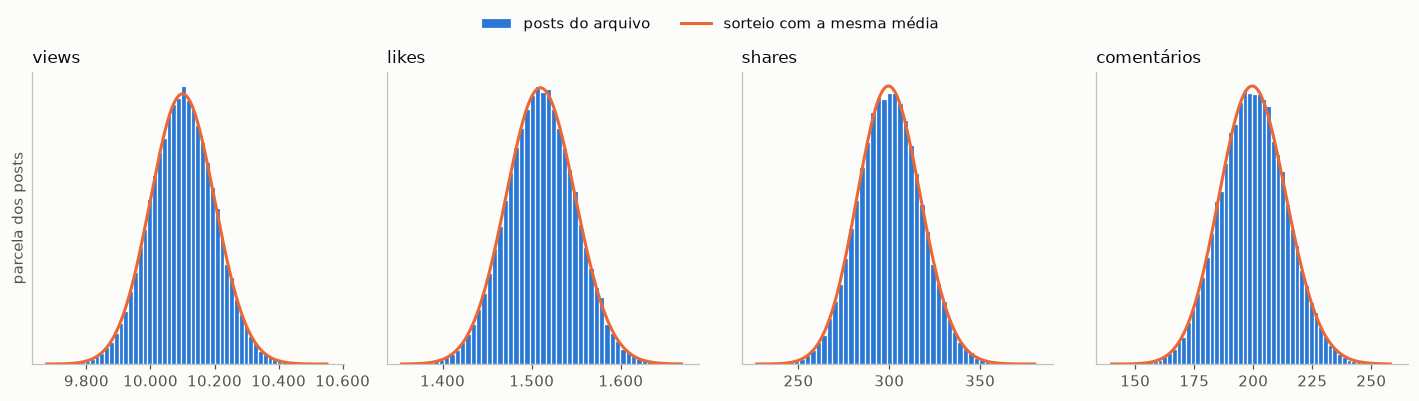

In [3]:
fig, eixos = plt.subplots(1, 4, figsize=(13, 3.4))
for ax, (nome, coluna) in zip(eixos, METRICAS.items()):
    valores = df[coluna]
    largura = max(1, int(np.ceil((valores.max() - valores.min()) / 60)))
    bordas = np.arange(valores.min(), valores.max() + largura + 1, largura) - 0.5
    ax.hist(valores, bins=bordas, density=True, color=AZUL, edgecolor=FUNDO, linewidth=0.8, label="posts do arquivo")
    x = np.arange(valores.min(), valores.max() + 1)
    ax.plot(x, stats.poisson.pmf(x, valores.mean()), color=LARANJA, linewidth=2, label="sorteio com a mesma média")
    ax.set_title(nome, loc="left")
    ax.set_yticks([])
    ax.grid(axis="x", visible=False)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: numero_br(v)))
eixos[0].set_ylabel("parcela dos posts")
fig.legend(*eixos[0].get_legend_handles_labels(), loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.08))
plt.tight_layout()
plt.show()

### 1.2 Teste 2: o mesmo creator aparece com números de seguidores muito diferentes

O número de seguidores de um creator muda devagar: de um post para o seguinte, a diferença costuma ser pequena. Se cada post traz um número sem relação com o anterior, a faixa do creator (nano, micro, mid, macro) não é confiável, e comparar resultados por faixa perde o sentido.

In [4]:
seguidores = variacao_seguidores(df)
posts_por_creator = df.groupby("creator_id").size()
print(f"{numero_br(len(seguidores))} creators, cada um com {posts_por_creator.min()} a {posts_por_creator.max()} posts")
print(f"Creators com número de seguidores diferente entre os próprios posts: {percentual_br((seguidores['razao'] > 1).mean(), 1)}")
print(f"Maior número dividido pelo menor, no mesmo creator (mediana entre creators): {numero_br(seguidores['razao'].median(), 1)} vezes")

5.000 creators, cada um com 10 a 11 posts
Creators com número de seguidores diferente entre os próprios posts: 100,0%
Maior número dividido pelo menor, no mesmo creator (mediana entre creators): 13,8 vezes


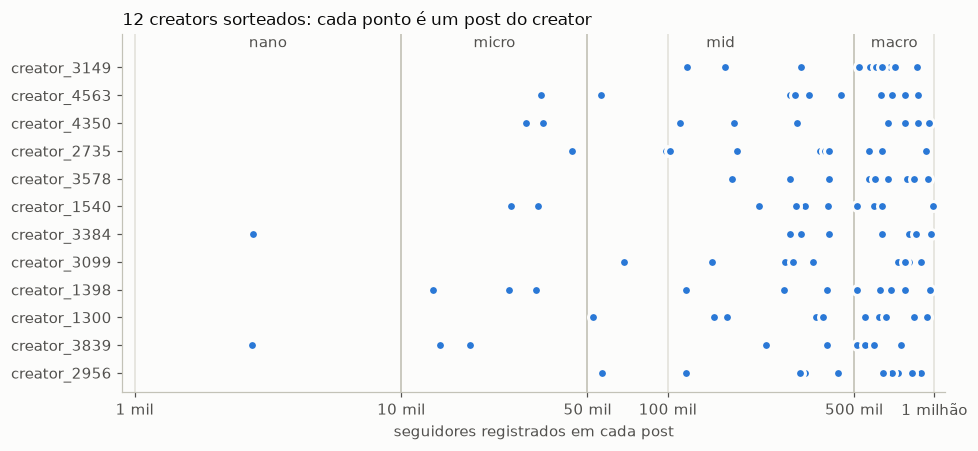

In [5]:
amostra = seguidores.sample(12, random_state=4).index
fig, ax = plt.subplots(figsize=(9, 4.2))
for i, creator in enumerate(amostra):
    valores = df.loc[df["creator_id"] == creator, "follower_count"]
    ax.scatter(valores, np.full(len(valores), i), s=42, color=AZUL, edgecolors=FUNDO, linewidths=2, zorder=3)
ax.set_xscale("log")
ax.minorticks_off()
for limite in LIMITES_FAIXA[1:-1]:
    ax.axvline(limite, color=EIXO, linewidth=1, zorder=1)
for inicio, fim, faixa in zip(LIMITES_FAIXA[:-1], LIMITES_FAIXA[1:], FAIXAS):
    centro = np.sqrt(max(inicio, 1_000) * min(fim, 1_000_000))
    ax.text(centro, len(amostra) - 0.4, faixa, ha="center", va="bottom", color=TINTA_2)
ax.set_xlim(900, 1_100_000)
ax.set_xticks([1_000, 10_000, 50_000, 100_000, 500_000, 1_000_000], ["1 mil", "10 mil", "50 mil", "100 mil", "500 mil", "1 milhão"])
ax.set_yticks(range(len(amostra)), amostra)
ax.set_ylim(-0.7, len(amostra) + 0.2)
ax.grid(axis="y", visible=False)
ax.set_xlabel("seguidores registrados em cada post")
ax.set_title("12 creators sorteados: cada ponto é um post do creator", loc="left")
plt.tight_layout()
plt.show()

Se o número de seguidores fosse sorteado por igual entre o menor e o maior valor do arquivo, quantos posts cairiam em cada faixa? A tabela compara essa conta com o arquivo.

In [6]:
esperado = proporcao_esperada_uniforme(LIMITES_FAIXA, df["follower_count"].min(), df["follower_count"].max())
teste2 = pd.DataFrame(
    {
        "posts": df["faixa_creator"].value_counts().reindex(FAIXAS),
        "parcela no arquivo": df["faixa_creator"].value_counts(normalize=True).reindex(FAIXAS),
        "parcela se fosse sorteio": esperado,
    }
)
(
    teste2.style.format(lambda v: percentual_br(v, 1))
    .format(lambda v: numero_br(v), subset=["posts"])
)

,posts,parcela no arquivo,parcela se fosse sorteio
faixa_creator,,,
nano,454,"0,9%","0,9%"
micro,2.110,"4,0%","4,0%"
mid,23.621,"45,2%","45,0%"
macro,26.029,"49,9%","50,1%"


In [7]:
print(f"Correlação entre seguidores e views: {numero_br(df['follower_count'].corr(df['views']), 3)} "
      "(0 = nenhuma relação; 1 = relação perfeita)")
por_faixa = df.groupby("faixa_creator", observed=True).agg(
    posts=("views", "size"), views_media=("views", "mean"), engajamento_medio=("engajamento", "mean")
)
(
    por_faixa.style.format(lambda v: numero_br(v), subset=["posts"])
    .format(lambda v: numero_br(v, 1), subset=["views_media"])
    .format(lambda v: numero_br(v, 4), subset=["engajamento_medio"])
)

Correlação entre seguidores e views: 0,005 (0 = nenhuma relação; 1 = relação perfeita)


,posts,views_media,engajamento_medio
faixa_creator,,,
nano,454,"10.090,6","0,1990"
micro,2.110,"10.101,3","0,1991"
mid,23.621,"10.099,5","0,1991"
macro,26.029,"10.101,1","0,1990"


### 1.3 Teste 3: as proporções são redondas demais e a alocação parece sorteada

Uma operação real não posta exatamente 60% em vídeo nem divide o público em 40% homens e 40% mulheres. Proporções redondas assim saem de um gerador configurado com percentuais fixos. O mesmo vale para a escolha do patrocinador: se ela dependesse do conteúdo, a mistura de categorias mudaria de um patrocinador para outro.

In [8]:
patrocinados = df[df["is_sponsored"]]
COLUNAS = {
    "plataforma": (df, "platform"), "formato": (df, "content_type"), "categoria": (df, "content_category"),
    "idioma": (df, "language"), "faixa etária do público": (df, "audience_age_distribution"),
    "gênero do público": (df, "audience_gender_distribution"), "país do público": (df, "audience_location"),
    "patrocinado": (df, "is_sponsored"), "categoria do patrocinador*": (patrocinados, "sponsor_category"),
    "tipo de divulgação*": (patrocinados, "disclosure_type"), "local da divulgação*": (patrocinados, "disclosure_location"),
}
for nome, (base, coluna) in COLUNAS.items():
    parcelas = base[coluna].value_counts(normalize=True)
    print(f"{nome:28s}" + " · ".join(f"{valor} {percentual_br(parcela, 1)}" for valor, parcela in parcelas.items()))
print("* só entre os posts patrocinados")

plataforma                  Bilibili 20,3% · YouTube 20,1% · Instagram 20,0% · RedNote 19,9% · TikTok 19,7%
formato                     video 60,3% · image 19,7% · mixed 10,0% · text 10,0%
categoria                   beauty 40,3% · lifestyle 39,8% · tech 20,0%
idioma                      English 50,0% · Chinese 20,0% · Hindi 10,1% · Spanish 10,0% · Japanese 9,9%
faixa etária do público     19-25 35,0% · 26-35 30,1% · 13-18 15,0% · 36-50 14,8% · 50+ 5,1%
gênero do público           male 40,2% · female 39,7% · non-binary 10,1% · unknown 10,0%
país do público             China 12,7% · UK 12,6% · Japan 12,6% · Brazil 12,5% · USA 12,4% · Germany 12,4% · India 12,4% · Russia 12,4%
patrocinado                 False 57,3% · True 42,7%
categoria do patrocinador*  food 17,2% · electronics 16,8% · fashion 16,6% · cosmetics 16,5% · gaming 16,5% · travel 16,3%
tipo de divulgação*         explicit 52,8% · implicit 47,2%
local da divulgação*        caption 40,1% · video 32,5% · hashtags 27,4%
* só en

In [9]:
contagem = pd.crosstab(patrocinados["sponsor_category"], patrocinados["content_category"])
qui2 = stats.chi2_contingency(contagem)
print(f"Teste de independência (qui-quadrado): p = {numero_br(qui2.pvalue, 2)}. "
      "p alto: nenhuma evidência de que a categoria do conteúdo dependa do patrocinador.")
contagem.div(contagem.sum(axis=1), axis=0).style.format(lambda v: percentual_br(v, 1))

Teste de independência (qui-quadrado): p = 0,70. p alto: nenhuma evidência de que a categoria do conteúdo dependa do patrocinador.


content_category,beauty,lifestyle,tech
sponsor_category,,,
cosmetics,"40,8%","39,6%","19,6%"
electronics,"39,0%","40,7%","20,3%"
fashion,"39,6%","39,5%","20,9%"
food,"39,8%","40,6%","19,6%"
gaming,"40,7%","39,6%","19,8%"
travel,"40,2%","39,0%","20,8%"


In [10]:
p_patrocinio = df["is_sponsored"].mean()
nunca = int((~df.groupby("creator_id")["is_sponsored"].any()).sum())
esperado_nunca = ((1 - p_patrocinio) ** posts_por_creator).sum()
print(f"Creators sem nenhum post patrocinado: {nunca} de {numero_br(len(posts_por_creator))}. "
      f"Se o patrocínio fosse sorteado post a post, o esperado seria {numero_br(esperado_nunca)}.")

Creators sem nenhum post patrocinado: 21 de 5.000. Se o patrocínio fosse sorteado post a post, o esperado seria 15.


### 1.4 Teste 4: os textos não fazem sentido

As descrições, os comentários e as hashtags parecem palavras em inglês sorteadas. Se o idioma do post fosse real, os posts marcados como chinês, japonês ou hindi teriam caracteres dessas línguas.

In [11]:
with pd.option_context("display.max_colwidth", 90):
    display(df.sample(4, random_state=1)[["language", "content_category", "content_description", "hashtags", "comments_text"]])

,language,content_category,content_description,hashtags,comments_text
47207,English,tech,Personal address produce affect young right those specific smile task usually Republic...,"go,music",Mr more ask vote bad fund order community. Performance pay factor control we system co...
27004,English,beauty,Summer I really environment debate stock full spend forward make whom market teach hou...,trial,Million baby purpose more recent.
44014,Spanish,tech,Leg eye behavior success become leave position note care anything drug control attenti...,"animal,fine",Another fund media economic.
8758,English,lifestyle,Budget half draw official small only garden decide billion task bit everybody several ...,"believe,move,quality",NaN


In [12]:
escrita = df.assign(tem_escrita_da_lingua=df["content_description"].map(usa_escrita_nao_latina))
por_idioma = (
    escrita.groupby("language")["tem_escrita_da_lingua"]
    .agg(posts="size", parcela_com_escrita_da_lingua="mean")
    .loc[["Chinese", "Japanese", "Hindi"]]
)
(
    por_idioma.style.format(lambda v: numero_br(v), subset=["posts"])
    .format(lambda v: percentual_br(v, 1), subset=["parcela_com_escrita_da_lingua"])
)

,posts,parcela_com_escrita_da_lingua
language,,
Chinese,10.428,"0,0%"
Japanese,5.177,"0,0%"
Hindi,5.272,"0,0%"


### 1.5 O método acha efeitos quando eles existem

Os testes acima dizem que o arquivo não tem diferenças entre grupos. Falta mostrar que isso não é defeito do método. O script `../validacao_metodo_simulacao.py` planta efeitos conhecidos (+15%, +10% e +3% no engajamento) em células sorteadas de uma cópia do dado e roda o mesmo método, 200 vezes para cada efeito. A tabela abaixo é a saída desse script. Nenhum número da análise vem da cópia com efeitos plantados.

- **taxa_sinal**: em quantas rodadas a célula plantada virou sinal.
- **taxa_abaixo_do_limiar**: em quantas o método percebeu a diferença, mas ela não passou de 10%.
- **falsos_positivos_por_rodada**: quantas outras células viraram sinal por engano, em média.

In [13]:
resumo_simulacao = pd.read_csv(PASTA_SOLUCAO / "resultados" / "validacao_metodo_resumo.csv")
(
    resumo_simulacao.style.hide(axis="index")
    .format(lambda v: percentual_br(v, 0, sinal=True), subset=["efeito"])
    .format(lambda v: percentual_br(v, 1), subset=["taxa_sinal", "taxa_abaixo_do_limiar"])
    .format(lambda v: percentual_br(v, 2, sinal=True), subset=["lift_medido_medio"])
    .format(lambda v: numero_br(v, 2), subset=["falsos_positivos_por_rodada"])
)

efeito,rodadas,taxa_sinal,taxa_abaixo_do_limiar,lift_medido_medio,falsos_positivos_por_rodada
+15%,200,"100,0%","0,0%","+15,04%","0,00"
+10%,200,"51,5%","48,5%","+10,02%","0,00"
+3%,200,"0,0%","99,5%","+3,01%","0,00"


## 2. Análise: as perguntas do Head de Marketing

Cada subseção responde a uma pergunta do brief com a mesma regra da seção 1: só é sinal a diferença que passa de 10%, continua confiável depois da correção para múltiplas comparações (Benjamini-Hochberg) e vem de pelo menos 30 posts. Cada grupo é comparado com todos os outros posts. A faixa do creator aparece só para completar as perguntas do brief: ela não é confiável (seção 1.2) e fica de fora das conclusões.

In [14]:
from src.celulas import mapa_celulas
from src.estatistica import classificar, efeito_estratificado
from src.hashtags import comparar_hashtags
from src.patrocinio import FIT_PATROCINIO, marcar_fit

DIMENSOES = ["platform", "content_category", "content_type"]
OBJETIVOS = {
    "engajamento": "engajamento",
    "alcance (views)": "views",
    "conversa (comentários por view)": "taxa_conversa",
    "compartilhamento (shares por view)": "taxa_compartilhamento",
}
CLASSES = ["sinal", "abaixo do limiar", "ruído", "poucos posts"]


def mostrar(tabela, colunas_texto):
    """Tabela de comparações com lift e intervalo de 95% em %, no formato brasileiro."""
    exibir = tabela[colunas_texto + ["n", "lift", "ic_inf", "ic_sup", "classe"]]
    return (
        exibir.style.hide(axis="index")
        .format(lambda v: numero_br(v), subset=["n"])
        .format(lambda v: percentual_br(v, 2, sinal=True), subset=["lift", "ic_inf", "ic_sup"])
    )


def resumir(mapas):
    """Uma linha por mapa: quantas comparações caíram em cada classe e a maior diferença testada."""
    linhas = {}
    for nome, mapa in mapas.items():
        testadas = mapa[mapa["classe"] != "poucos posts"]
        linhas[nome] = {
            "comparações": len(mapa),
            **mapa["classe"].value_counts().reindex(CLASSES, fill_value=0).to_dict(),
            "maior diferença": testadas.loc[testadas["lift"].abs().idxmax(), "lift"],
        }
    return (
        pd.DataFrame(linhas).T.style
        .format(lambda v: numero_br(v), subset=["comparações"] + CLASSES)
        .format(lambda v: percentual_br(v, 2, sinal=True), subset=["maior diferença"])
    )

### 2.1 O que gera engajamento?

Primeiro, cada característica sozinha: cada plataforma, formato, categoria e faixa, comparada com todos os outros posts.

In [15]:
CARACTERISTICAS = {"plataforma": "platform", "formato": "content_type", "categoria": "content_category", "faixa do creator*": "faixa_creator"}
uma_por_vez = pd.concat(
    [mapa_celulas(df, [coluna]).rename(columns={coluna: "valor"}).assign(caracteristica=nome) for nome, coluna in CARACTERISTICAS.items()],
    ignore_index=True,
)
uma_por_vez["valor"] = uma_por_vez["valor"].astype(str)
print("* faixa do creator não é confiável (seção 1.2)")
mostrar(uma_por_vez, ["caracteristica", "valor"])

* faixa do creator não é confiável (seção 1.2)


caracteristica,valor,n,lift,ic_inf,ic_sup,classe
plataforma,Bilibili,10.598,"+0,02%","-0,03%","+0,07%",ruído
plataforma,Instagram,10.423,"-0,04%","-0,09%","+0,01%",ruído
plataforma,RedNote,10.402,"+0,03%","-0,03%","+0,08%",ruído
plataforma,TikTok,10.296,"+0,00%","-0,05%","+0,06%",ruído
plataforma,YouTube,10.495,"-0,01%","-0,06%","+0,04%",ruído
formato,image,10.303,"-0,01%","-0,06%","+0,04%",ruído
formato,mixed,5.213,"+0,05%","-0,02%","+0,12%",ruído
formato,text,5.198,"+0,05%","-0,02%","+0,12%",ruído
formato,video,31.500,"-0,03%","-0,07%","+0,01%",ruído
categoria,beauty,21.023,"+0,00%","-0,04%","+0,04%",ruído


Depois, as combinações de plataforma, categoria e formato (o mapa de células), para quatro formas de medir resultado: engajamento geral, alcance (views), conversa (comentários por view) e compartilhamento (shares por view). É a pergunta "o que funciona, onde e para quê".

In [16]:
mapas = {nome: mapa_celulas(df, DIMENSOES, metrica=coluna) for nome, coluna in OBJETIVOS.items()}
print(f"{len(mapas['engajamento'])} células; a menor tem {numero_br(mapas['engajamento']['n'].min())} posts")
resumir(mapas)

60 células; a menor tem 187 posts


,comparações,sinal,abaixo do limiar,ruído,poucos posts,maior diferença
engajamento,60,0,0,60,0,"+0,28%"
alcance (views),60,0,0,60,0,"-0,16%"
conversa (comentários por view),60,0,0,60,0,"+0,86%"
compartilhamento (shares por view),60,0,0,60,0,"+0,66%"


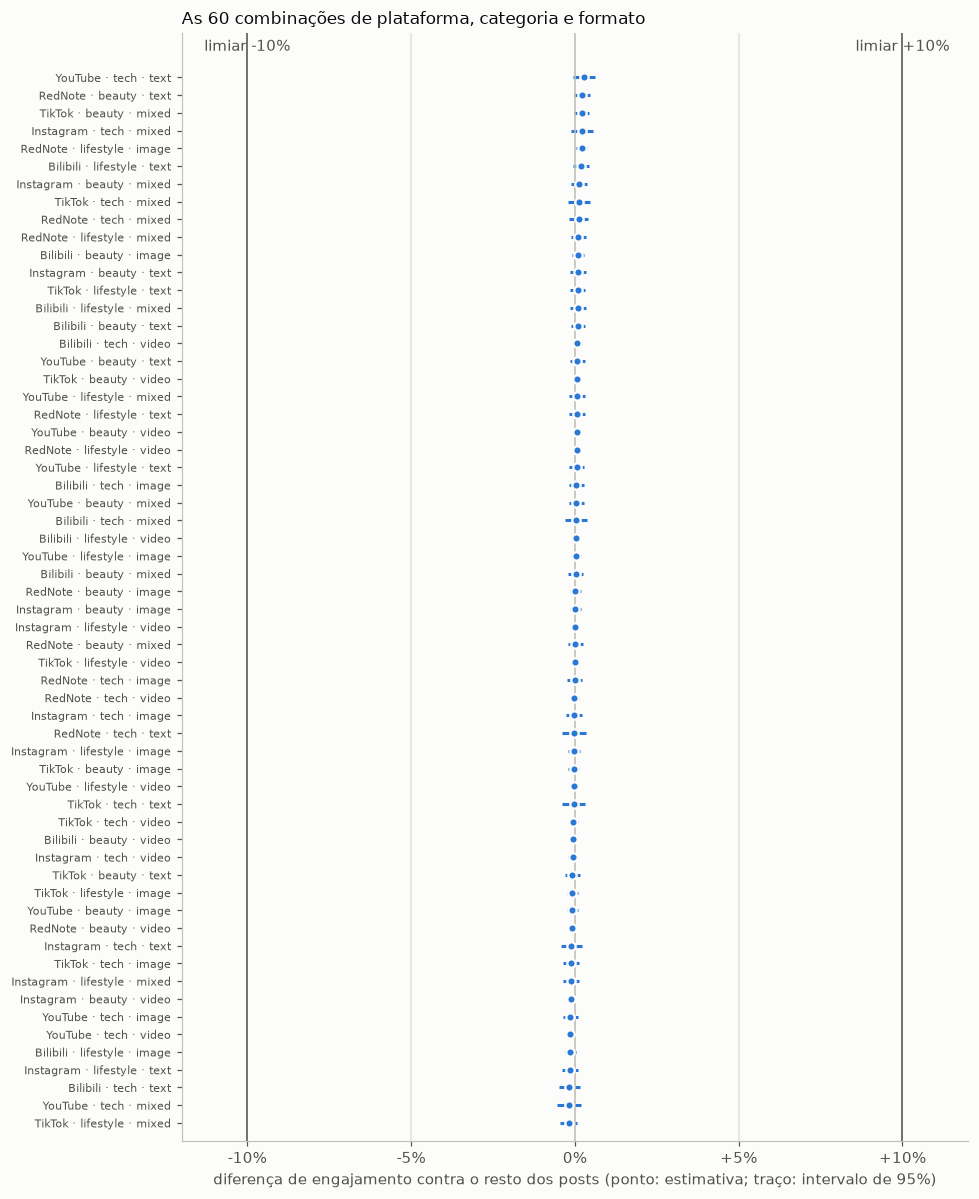

In [17]:
mapa = mapas["engajamento"].sort_values("lift").reset_index(drop=True)
rotulos = mapa["platform"] + " · " + mapa["content_category"] + " · " + mapa["content_type"]
y = np.arange(len(mapa))
fig, ax = plt.subplots(figsize=(9, 11))
ax.hlines(y, mapa["ic_inf"] * 100, mapa["ic_sup"] * 100, color=AZUL, linewidth=2)
ax.scatter(mapa["lift"] * 100, y, s=30, color=AZUL, edgecolors=FUNDO, linewidths=1.5, zorder=3)
ax.axvline(0, color=EIXO, linewidth=1)
for limite in (-10, 10):
    ax.axvline(limite, color=TINTA_2, linewidth=1)
    ax.text(limite, len(mapa) + 0.3, f"limiar {limite:+d}%", ha="center", va="bottom", color=TINTA_2)
ax.set_yticks(y, rotulos, fontsize=7.5)
ax.set_xlim(-12, 12)
ax.set_ylim(-1, len(mapa) + 1.5)
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: "0%" if v == 0 else f"{v:+.0f}%"))
ax.grid(axis="y", visible=False)
ax.set_xlabel("diferença de engajamento contra o resto dos posts (ponto: estimativa; traço: intervalo de 95%)")
ax.set_title("As 60 combinações de plataforma, categoria e formato", loc="left")
plt.tight_layout()
plt.show()

### 2.2 Patrocínio funciona? Em que condições?

Duas comparações para cada objetivo. A **direta** põe todos os patrocinados contra todos os orgânicos. A **justa** compara patrocinado com orgânico só dentro da mesma plataforma, categoria e formato, para que diferenças de mix não se passem por efeito do patrocínio. A faixa do creator fica de fora do controle, porque não é confiável.

In [18]:
linhas = []
for nome, coluna in OBJETIVOS.items():
    direta = mapa_celulas(df, ["is_sponsored"], metrica=coluna).set_index("is_sponsored").loc[True]
    justa = efeito_estratificado(df, "is_sponsored", DIMENSOES, coluna)
    linhas.append({"objetivo": nome, "comparação": "direta", "n": direta["n"], "lift": direta["lift"],
                   "ic_inf": direta["ic_inf"], "ic_sup": direta["ic_sup"], "p": direta["p"]})
    linhas.append({"objetivo": nome, "comparação": "justa", "n": justa["n_tratados"], "lift": justa["lift"],
                   "ic_inf": justa["ic_inf"], "ic_sup": justa["ic_sup"], "p": justa["p"]})
patrocinio = pd.concat([classificar(grupo) for _, grupo in pd.DataFrame(linhas).groupby("comparação", sort=False)])
mostrar(patrocinio, ["objetivo", "comparação"])

objetivo,comparação,n,lift,ic_inf,ic_sup,classe
engajamento,direta,22.314,"-0,01%","-0,05%","+0,04%",ruído
alcance (views),direta,22.314,"+0,00%","-0,01%","+0,02%",ruído
conversa (comentários por view),direta,22.314,"+0,02%","-0,11%","+0,14%",ruído
compartilhamento (shares por view),direta,22.314,"-0,05%","-0,15%","+0,06%",ruído
engajamento,justa,22.314,"-0,01%","-0,05%","+0,04%",ruído
alcance (views),justa,22.314,"+0,00%","-0,01%","+0,02%",ruído
conversa (comentários por view),justa,22.314,"+0,02%","-0,11%","+0,14%",ruído
compartilhamento (shares por view),justa,22.314,"-0,04%","-0,15%","+0,06%",ruído


Em que condições? Entre os posts patrocinados, cada condição é comparada com os outros patrocinados: tipo e local da divulgação, categoria do patrocinador e se o patrocinador combina com o conteúdo. Para "combinar", usamos um mapa declarado como premissa: cosméticos com beauty; moda com beauty e lifestyle; eletrônicos e games com tech; comida e viagem com lifestyle.

In [19]:
patrocinados = df[df["is_sponsored"]].copy()
patrocinados["fit"] = marcar_fit(patrocinados).map({True: "combina", False: "não combina"})
CONDICOES = {
    "tipo de divulgação": "disclosure_type", "local da divulgação": "disclosure_location",
    "categoria do patrocinador": "sponsor_category", "patrocinador x conteúdo": "fit", "faixa do creator*": "faixa_creator",
}
condicoes = pd.concat(
    [mapa_celulas(patrocinados, [coluna]).rename(columns={coluna: "valor"}).assign(condicao=nome) for nome, coluna in CONDICOES.items()],
    ignore_index=True,
)
condicoes["valor"] = condicoes["valor"].astype(str)
print("* faixa do creator não é confiável (seção 1.2)")
mostrar(condicoes, ["condicao", "valor"])

* faixa do creator não é confiável (seção 1.2)


condicao,valor,n,lift,ic_inf,ic_sup,classe
tipo de divulgação,explicit,11.784,"+0,04%","-0,02%","+0,11%",ruído
tipo de divulgação,implicit,10.530,"-0,04%","-0,11%","+0,02%",ruído
local da divulgação,caption,8.944,"-0,06%","-0,12%","+0,01%",ruído
local da divulgação,hashtags,6.124,"+0,05%","-0,03%","+0,12%",ruído
local da divulgação,video,7.246,"+0,02%","-0,05%","+0,09%",ruído
categoria do patrocinador,cosmetics,3.688,"+0,07%","-0,02%","+0,15%",ruído
categoria do patrocinador,electronics,3.750,"+0,00%","-0,09%","+0,09%",ruído
categoria do patrocinador,fashion,3.710,"-0,09%","-0,17%","+0,00%",ruído
categoria do patrocinador,food,3.846,"+0,04%","-0,05%","+0,12%",ruído
categoria do patrocinador,gaming,3.687,"-0,03%","-0,12%","+0,05%",ruído


Como a operação patrocina: o que o registro mostra sobre as escolhas, independentemente do resultado. O arquivo não tem nenhuma coluna de custo; o custo implícito fica na estratégia, como premissa declarada.

In [20]:
parcela_conteudo = df["content_category"].value_counts(normalize=True)
esperado_fit = patrocinados["sponsor_category"].map(lambda s: parcela_conteudo[sorted(FIT_PATROCINIO[s])].sum()).mean()
por_patrocinador = patrocinados["sponsor_name"].value_counts()
print(f"Posts patrocinados: {numero_br(len(patrocinados))} ({percentual_br(len(patrocinados) / len(df), 1)} do total)")
print(f"Patrocinador combina com o conteúdo: {percentual_br((patrocinados['fit'] == 'combina').mean(), 1)} "
      f"(se a escolha fosse sorteada: {percentual_br(esperado_fit, 1)})")
print(f"Patrocinadores diferentes: {numero_br(len(por_patrocinador))}; aparecem em um post só: "
      f"{percentual_br((por_patrocinador == 1).mean(), 1)}; o que mais aparece tem {por_patrocinador.max()} posts")
for nome, coluna in {"plataforma": "platform", "categoria": "content_category", "formato": "content_type"}.items():
    taxa = df.groupby(coluna)["is_sponsored"].mean()
    print(f"Parcela patrocinada por {nome}: de {percentual_br(taxa.min(), 1)} a {percentual_br(taxa.max(), 1)}")
print(f"Divulgação implícita: {percentual_br((patrocinados['disclosure_type'] == 'implicit').mean(), 1)}; "
      f"só nas hashtags: {percentual_br((patrocinados['disclosure_location'] == 'hashtags').mean(), 1)}")

Posts patrocinados: 22.314 (42,7% do total)
Patrocinador combina com o conteúdo: 39,9% (se a escolha fosse sorteada: 39,9%)
Patrocinadores diferentes: 18.005; aparecem em um post só: 90,0%; o que mais aparece tem 32 posts
Parcela patrocinada por plataforma: de 41,9% a 43,5%
Parcela patrocinada por categoria: de 42,5% a 43,1%
Parcela patrocinada por formato: de 42,4% a 42,9%
Divulgação implícita: 47,2%; só nas hashtags: 27,4%


### 2.3 Qual audiência mais engaja?

O arquivo traz um rótulo de público por post (faixa etária, gênero, país), não uma distribuição. Primeiro, cada rótulo contra o resto. Depois, cada tipo de rótulo combinado com plataforma, formato e categoria, para ver se o público que engaja muda de uma para outra.

In [21]:
PUBLICO = {"faixa etária": "audience_age_distribution", "gênero": "audience_gender_distribution", "país": "audience_location"}
publico = pd.concat(
    [mapa_celulas(df, [coluna]).rename(columns={coluna: "valor"}).assign(publico=nome) for nome, coluna in PUBLICO.items()],
    ignore_index=True,
)
mostrar(publico, ["publico", "valor"])

publico,valor,n,lift,ic_inf,ic_sup,classe
faixa etária,13-18,7.852,"-0,04%","-0,10%","+0,02%",ruído
faixa etária,19-25,18.276,"+0,04%","-0,01%","+0,08%",ruído
faixa etária,26-35,15.700,"-0,01%","-0,06%","+0,03%",ruído
faixa etária,36-50,7.736,"-0,02%","-0,08%","+0,04%",ruído
faixa etária,50+,2.650,"+0,03%","-0,06%","+0,13%",ruído
gênero,female,20.743,"-0,00%","-0,04%","+0,04%",ruído
gênero,male,20.987,"+0,00%","-0,04%","+0,04%",ruído
gênero,non-binary,5.249,"-0,00%","-0,07%","+0,07%",ruído
gênero,unknown,5.235,"+0,00%","-0,07%","+0,07%",ruído
país,Brazil,6.505,"+0,04%","-0,03%","+0,10%",ruído


In [22]:
OUTRAS = {"plataforma": "platform", "formato": "content_type", "categoria": "content_category"}
combinados = {
    f"{nome} x {outra}": mapa_celulas(df, [coluna, outra_coluna])
    for nome, coluna in PUBLICO.items()
    for outra, outra_coluna in OUTRAS.items()
}
resumir(combinados)

,comparações,sinal,abaixo do limiar,ruído,poucos posts,maior diferença
faixa etária x plataforma,25,0,0,25,0,"+0,14%"
faixa etária x formato,20,0,0,20,0,"+0,13%"
faixa etária x categoria,15,0,0,15,0,"-0,13%"
gênero x plataforma,20,0,0,20,0,"-0,07%"
gênero x formato,16,0,0,16,0,"+0,08%"
gênero x categoria,12,0,0,12,0,"-0,11%"
país x plataforma,40,0,0,40,0,"+0,21%"
país x formato,32,0,0,32,0,"+0,23%"
país x categoria,24,0,0,24,0,"-0,14%"


### 2.4 O que não funciona?

Pelo resultado, nenhum grupo fica acima ou abaixo do resto além do limiar (2.1 a 2.3). Duas conferências a mais. A primeira é a dica do brief sobre viés de sobrevivência: quantos posts deram errado? A segunda são as hashtags, onde a quantidade de comparações mostra por que a correção é necessária.

In [23]:
print(f"Engajamento por post: de {percentual_br(df['engajamento'].min(), 1)} a {percentual_br(df['engajamento'].max(), 1)}; "
      f"posts com engajamento zero: {(df['engajamento'] == 0).sum()}")
print(f"Views por post: de {numero_br(df['views'].min())} a {numero_br(df['views'].max())}")

Engajamento por post: de 17,9% a 22,2%; posts com engajamento zero: 0
Views por post: de 9.676 a 10.551


In [24]:
hashtags = comparar_hashtags(df, minimo=100)
distintas = df["hashtags"].dropna().str.split(",").explode().str.strip().nunique()
print(f"Hashtags diferentes: {numero_br(distintas)}; usadas em 100 posts ou mais (testadas): {numero_br(len(hashtags))}")
print(f"Com p < 0,05 sem correção (pareceriam campeãs ou vilãs): {numero_br((hashtags['p'] < 0.05).sum())}")
print(f"Confiáveis depois da correção: {numero_br((hashtags['p_ajustado'] < 0.05).sum())}; viram sinal: {numero_br((hashtags['classe'] == 'sinal').sum())}")
print(f"Maior diferença entre as testadas: {percentual_br(hashtags.loc[hashtags['lift'].abs().idxmax(), 'lift'], 2, sinal=True)}")

Hashtags diferentes: 972; usadas em 100 posts ou mais (testadas): 970
Com p < 0,05 sem correção (pareceriam campeãs ou vilãs): 59
Confiáveis depois da correção: 0; viram sinal: 0
Maior diferença entre as testadas: -0,72%


### 2.5 Onde concentrar e com que frequência?

Volume de postagem, dia da semana, hora, mês e a duração dos vídeos (o exemplo do brief: "vídeos de 30 a 60 segundos"). O arquivo não documenta a unidade de `content_length`; em vídeo, tratamos como segundos. A distribuição dessa coluna é a mesma em todos os formatos (de 10 a 599), o que é mais um sinal de dado gerado.

In [25]:
por_dia = df.groupby(df["post_date"].dt.date).agg(posts=("id", "size"), engajamento=("engajamento", "mean"))
correlacao = stats.pearsonr(por_dia["posts"], por_dia["engajamento"])
print(f"Posts por dia: média de {numero_br(por_dia['posts'].mean(), 1)} (de {por_dia['posts'].min()} a {por_dia['posts'].max()}), em {len(por_dia)} dias")
print(f"Por plataforma e por dia: {numero_br(por_dia['posts'].mean() / df['platform'].nunique(), 1)}; "
      f"por creator: {numero_br(len(df) / df['creator_id'].nunique(), 1)} posts em dois anos")
print(f"Correlação entre o número de posts do dia e o engajamento médio do dia: {numero_br(correlacao.statistic, 3)} "
      f"(p = {numero_br(correlacao.pvalue, 2)})")

Posts por dia: média de 71,4 (de 31 a 98), em 731 dias
Por plataforma e por dia: 14,3; por creator: 10,4 posts em dois anos
Correlação entre o número de posts do dia e o engajamento médio do dia: 0,070 (p = 0,06)


In [26]:
DIAS = ["segunda", "terça", "quarta", "quinta", "sexta", "sábado", "domingo"]
tempo = df.assign(
    dia_da_semana=df["post_date"].dt.dayofweek.map(dict(enumerate(DIAS))),
    hora=df["post_date"].dt.hour,
    mes=df["post_date"].dt.strftime("%Y-%m"),
)
videos = df[df["content_type"] == "video"].assign(
    duracao=lambda d: pd.cut(d["content_length"], [0, 30, 60, 180, np.inf], right=False, labels=["até 30", "30 a 60", "60 a 180", "180 ou mais"])
)
mapas_tempo = {
    "dia da semana": mapa_celulas(tempo, ["dia_da_semana"]),
    "hora do dia": mapa_celulas(tempo, ["hora"]),
    "mês": mapa_celulas(tempo, ["mes"]),
    "duração do vídeo x categoria (engajamento)": mapa_celulas(videos, ["duracao", "content_category"]),
    "duração do vídeo x categoria (compartilhamento)": mapa_celulas(videos, ["duracao", "content_category"], metrica="taxa_compartilhamento"),
}
resumir(mapas_tempo)

,comparações,sinal,abaixo do limiar,ruído,poucos posts,maior diferença
dia da semana,7,0,0,7,0,"+0,05%"
hora do dia,24,0,0,24,0,"+0,14%"
mês,25,0,0,25,0,"-0,09%"
duração do vídeo x categoria (engajamento),12,0,0,12,0,"-0,16%"
duração do vídeo x categoria (compartilhamento),12,0,0,12,0,"+0,32%"
